In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. Load Data
# ============================================================================
file_path = 'Data_Merged_with_SMILES.xlsx'
df = pd.read_excel(file_path)
print(f"✓ Data loaded: {len(df)} records")

✓ Data loaded: 1573 records


In [2]:
# ============================================================================
# 2. Functional Group Definitions (Using RDKit SMARTS)
# ============================================================================
FUNCTIONAL_GROUPS = {
    # Electron-withdrawing groups (lower LUMO)
    'Fluorine': '[F]',
    'Chlorine': '[Cl]',
    'Cyano': 'C#N',
    'Carbonyl': 'C=O',
    # Electron-donating/conjugated groups (affect HOMO/bandgap)
    'Thiophene_S': '[s]',
    'Ether_O': '[!#1][O][!#1]',
    'Alkyl_Long': '[CH3][CH2][CH2][CH2][CH2]',
    # Core structures
    'Benzothiadiazole': 'n1snc1',
    'Indacene': 'c1ccc2c(c1)sc3ccccc23',
}

failed_records = []

def extract_features(smiles, role='Acc'):
    """Extract functional group features using RDKit"""
    if not isinstance(smiles, str) or len(smiles) < 5:
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        Chem.SanitizeMol(mol)

        features = {}
        for name, smarts in FUNCTIONAL_GROUPS.items():
            pattern = Chem.MolFromSmarts(smarts)
            if pattern:
                count = len(mol.GetSubstructMatches(pattern))
                features[f'{name}_Count'] = count
                features[f'{name}_Present'] = int(count > 0)

        # Add basic descriptors
        features['MolWt'] = Descriptors.MolWt(mol)
        features['LogP'] = Descriptors.MolLogP(mol)
        return features
    except:
        return None


In [3]:
# ============================================================================
# 3. Feature Engineering
# ============================================================================
print("Extracting molecular features...")

# Extract acceptor features (function returns keys without prefix)
acc_feats = [extract_features(row['SMILES_acc'], role='Acc') for _, row in df.iterrows()]
acc_df = pd.DataFrame([f if f else {} for f in acc_feats]).add_prefix('Acc_')

# Extract donor features
don_feats = [extract_features(row['SMILES_don'], role='Don') for _, row in df.iterrows()]
don_df = pd.DataFrame([f if f else {} for f in don_feats]).add_prefix('Don_')

# Merge data
df_feat = pd.concat([df, acc_df, don_df], axis=1)

# Quick fix: If there are still duplicate prefixes, rename them
df_feat = df_feat.rename(columns=lambda x: x.replace('Acc_Acc_', 'Acc_').replace('Don_Don_', 'Don_'))

# Filter valid samples (now column names are correct)
valid_mask = df_feat['Acc_MolWt'] > 0
df_ml = df_feat[valid_mask].dropna(subset=['HOMO_A', 'LUMO_A', 'EgCV_A', 'EgA_opt'])
print(f"✓ Valid samples: {len(df_ml)} / {len(df)}")

# Define feature columns and target variables
FEATURE_COLS = [c for c in df_feat.columns if
                c.startswith('Acc_') and
                ('_Count' in c or '_Present' in c or c in ['Acc_MolWt', 'Acc_LogP'])]
TARGETS = {
    'HOMO_A': 'HOMO Energy Level (eV)',
    'LUMO_A': 'LUMO Energy Level (eV)',
    'EgCV_A': 'Cyclic Voltammetry Bandgap (eV)',
    'EgA_opt': 'Optical Bandgap (eV)'
}


Extracting molecular features...


[21:37:13] SMILES Parse Error: ring closure 1 duplicates bond between atom 35 and atom 36 for input: 'CCCCCCCCCCCc3c(C=c2c(=O)c1cc(Cl)c(Cl)cc1c2=C(C#N)C#N)[Se]c12c3sc11c10c4nsnc4c9c8sc7c(CCCCCCCCCCC)c(C=c6c(=O)c5cc(Cl)c(Cl)cc5c6=C(C#N)C#N)[Se]c7c8n(CC(CCCC)CCCCCC)c9c10n(CC(CCCC)CCCCCC)c11c12'
[21:37:13] SMILES Parse Error: duplicated ring closure 1 bonds atom 32 to itself for input: 'CCCCCCCCCCCc3c(C=c2c(=O)c1cc(Cl)c(Cl)cc1c2=C(C#N)C#N)sc11c3sc12c10c4nsnc4c9c8sc7c(CCCCCCCCCCC)c(C=c6c(=O)c5cc(Cl)c(Cl)cc5c6=C(C#N)C#N)[Se]c7c8n(CC(CCCC)CCCCCC)c9c10n(CC(CCCC)CCCCCC)c11c12'
[21:37:17] SMILES Parse Error: unclosed ring for input: 'CCCCC(CC)CC1=C(C=C(S1)C2=C3C=C(SC3=C(C4=C2SC(=C4)C5=CC=C(S5)C6=C7C(=C(S6)C8=CC=C(S8)C)C(=O)[Ir]C8=C(SC(=C9C7=O)CC(CC)CCCC)CC(CC)CCCC)C1=CC(=C(S1)CC(CC)CCCC)F)C)F'
[21:37:17] SMILES Parse Error: unclosed ring for input: 'CCCCC(CC)CC1=C(C=C(S1)C2=C3C=C(SC3=C(C4=C2SC(=C4)C5=CC=C(S5)C6=C7C(=C(S6)C8=CC=C(S8)C)C(=O)[Ir]C8=C(SC(=C9C7=O)CC(CC)CCCC)CC(CC)CCCC)C1=CC(=C(S1)CC

✓ Valid samples: 1571 / 1573


In [4]:
# ============================================================================
# 4. Random Forest Modeling + Feature Importance Analysis
# ============================================================================
print("\n" + "="*60)
print("Random Forest Model Training - Functional Group → Electronic Property Mapping")
print("="*60)

results = {}

for target, desc in TARGETS.items():
    if target not in df_ml.columns:
        continue

    print(f"\n▶ Target: {target} - {desc}")
    X = df_ml[FEATURE_COLS].fillna(0)
    y = df_ml[target]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    # Train RF
    rf = RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_leaf=3,
        random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # Evaluate
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv_r2 = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2').mean()

    print(f"  R² = {r2:.3f} | MAE = {mae:.3f} | CV-R² = {cv_r2:.3f}")

    # Feature importance
    feat_imp = pd.DataFrame({
        'Feature': FEATURE_COLS,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)

    results[target] = {
        'model': rf, 'r2': r2, 'mae': mae, 'cv_r2': cv_r2,
        'importance': feat_imp, 'features': FEATURE_COLS
    }

    # Output Top 5 important functional groups
    print("  Top 5 Key Functional Groups:")
    for i, row in feat_imp.head(5).iterrows():
        name = row['Feature'].replace('Acc_', '').replace('_Count', '').replace('_Present', '')
        print(f"    • {name}: {row['Importance']:.4f}")


Random Forest Model Training - Functional Group → Electronic Property Mapping

▶ Target: HOMO_A - HOMO Energy Level (eV)
  R² = 0.273 | MAE = 0.081 | CV-R² = 0.121
  Top 5 Key Functional Groups:
    • LogP: 0.3736
    • MolWt: 0.2687
    • Thiophene_S: 0.1053
    • Ether_O: 0.0642
    • Fluorine: 0.0494

▶ Target: LUMO_A - LUMO Energy Level (eV)
  R² = 0.151 | MAE = 0.101 | CV-R² = 0.090
  Top 5 Key Functional Groups:
    • LogP: 0.3533
    • MolWt: 0.2935
    • Thiophene_S: 0.1011
    • Fluorine: 0.0495
    • Ether_O: 0.0405

▶ Target: EgCV_A - Cyclic Voltammetry Bandgap (eV)
  R² = 0.114 | MAE = 0.113 | CV-R² = 0.003
  Top 5 Key Functional Groups:
    • LogP: 0.3515
    • MolWt: 0.3228
    • Thiophene_S: 0.1370
    • Fluorine: 0.0378
    • Ether_O: 0.0377

▶ Target: EgA_opt - Optical Bandgap (eV)
  R² = 0.335 | MAE = 0.077 | CV-R² = 0.207
  Top 5 Key Functional Groups:
    • LogP: 0.3726
    • Thiophene_S: 0.2285
    • MolWt: 0.1920
    • Fluorine: 0.0550
    • Carbonyl: 0.0338



✓ Visualization saved: functional_group_effects.png


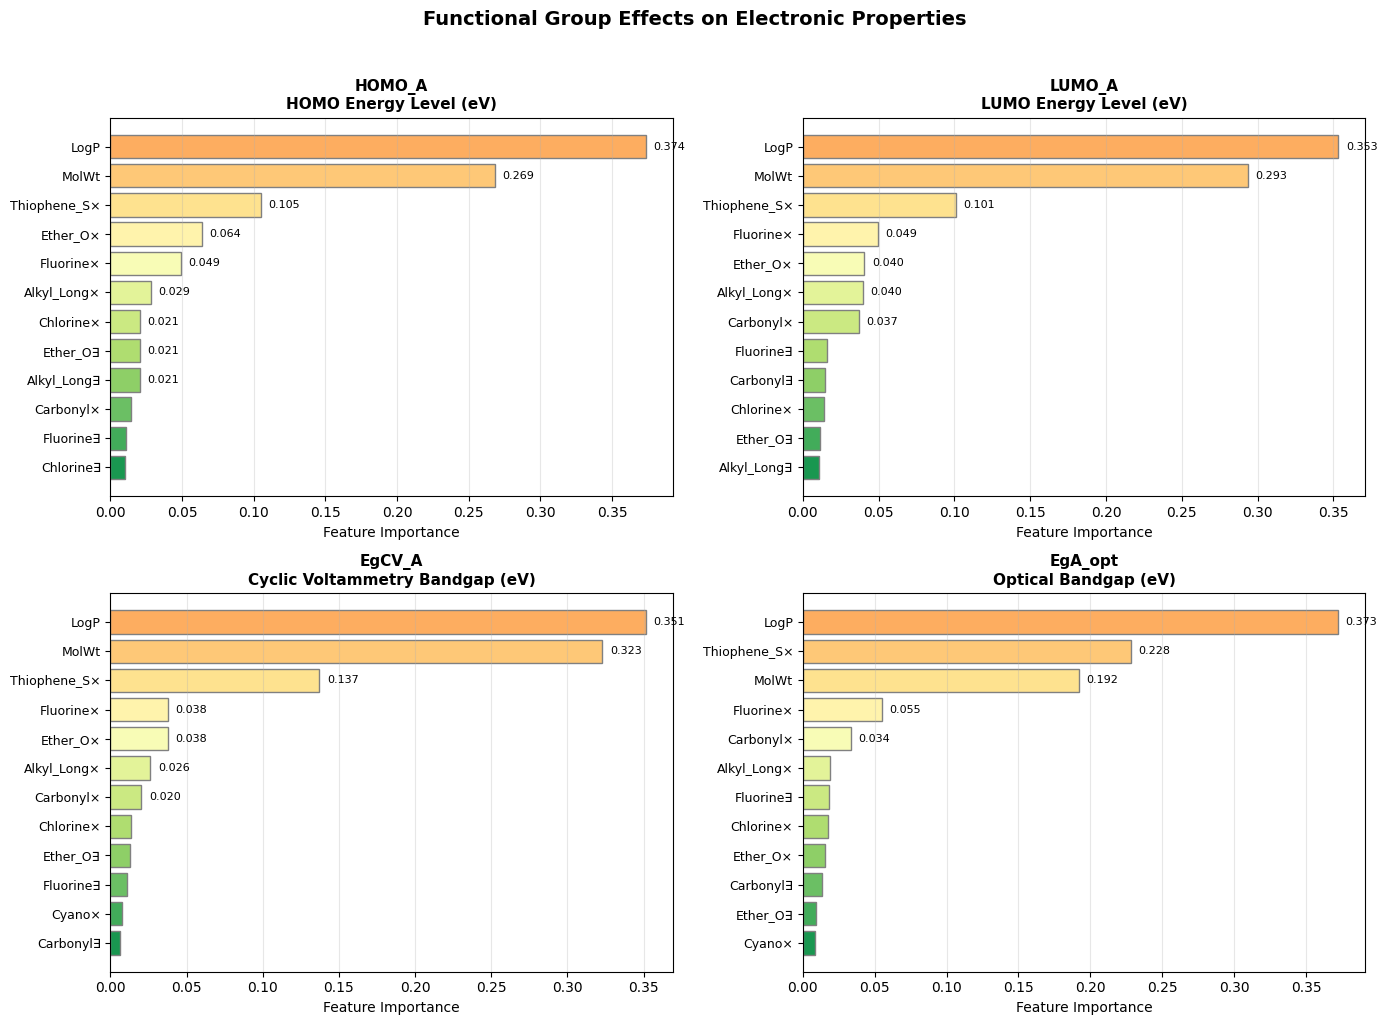

In [5]:
# ============================================================================
# 5. Visualization: Functional Group Effects Analysis
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Functional Group Effects on Electronic Properties',
             fontsize=14, fontweight='bold', y=1.02)

# Figures 1-4: Feature importance for each target variable
for idx, (target, desc) in enumerate(TARGETS.items()):
    if target not in results:
        continue
    ax = axes[idx//2, idx%2]
    imp = results[target]['importance'].head(12)

    # Clean feature names for display
    labels = [f.replace('Acc_', '').replace('_Count', '×').replace('_Present', '∃')
              for f in imp['Feature']]

    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(imp)))
    bars = ax.barh(range(len(imp)), imp['Importance'], color=colors, edgecolor='gray')

    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.set_title(f'{target}\n{desc}', fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, imp['Importance'])):
        if val > 0.02:  # Only show important features
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                   f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('functional_group_effects.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualization saved: functional_group_effects.png")
plt.show()

In [6]:
# ============================================================================
# 6. Functional Group Effect Prediction Tool (Core Functionality)
# ============================================================================
class FunctionalGroupEffectPredictor:
    """
    Predict the effect of adding/removing functional groups on electronic properties
    Based on trained random forest models + feature perturbation analysis
    """

    def __init__(self, results_dict, feature_cols, df_reference):
        self.models = {t: r['model'] for t, r in results_dict.items()}
        self.feature_cols = feature_cols
        self.df_ref = df_reference  # For reference distribution

    def _build_feature_vector(self, base_features, modification):
        """Build new feature vector based on modification"""
        new_feats = base_features.copy()
        for key, delta in modification.items():
            # key format: "Acc_Fluorine_Count" or "Acc_Cyano_Present"
            if key in new_feats:
                if '_Count' in key:
                    new_feats[key] = max(0, new_feats[key] + delta)
                elif '_Present' in key:
                    new_feats[key] = 1 if delta > 0 else 0
        return new_feats

    def predict_effect(self, molecule_idx, modification, target='LUMO_A'):
        """
        Predict modification effect on a single molecule

        Parameters:
        - molecule_idx: Molecule index in the dataset
        - modification: dict, e.g., {'Acc_Fluorine_Count': +2, 'Acc_Cyano_Count': -1}
        - target: Target property ('HOMO_A', 'LUMO_A', 'EgCV_A', 'EgA_opt')

        Returns:
        - dict: Contains original value, predicted value, change amount
        """
        if target not in self.models:
            return {'error': f'Target {target} not available'}

        # Get original features
        orig_row = self.df_ref.iloc[molecule_idx]
        orig_feats = {c: orig_row[c] if c in orig_row else 0 for c in self.feature_cols}

        # Original prediction (validate model)
        orig_pred = self.models[target].predict([pd.Series(orig_feats)])[0]
        orig_actual = orig_row[target]

        # Modified features
        new_feats = self._build_feature_vector(orig_feats, modification)
        new_pred = self.models[target].predict([pd.Series(new_feats)])[0]

        # Calculate effect
        effect = new_pred - orig_actual  # Change relative to actual value

        return {
            'molecule': orig_row.get('Acceptor', f'Idx_{molecule_idx}'),
            'target': target,
            'original_value': round(orig_actual, 3),
            'predicted_original': round(orig_pred, 3),
            'predicted_modified': round(new_pred, 3),
            'predicted_change': round(new_pred - orig_pred, 4),
            'estimated_effect': round(effect, 4),
            'modification': modification,
            'confidence': 'high' if abs(new_pred - orig_pred) > 0.05 else 'low'
        }

    def suggest_optimal_modifications(self, target='LUMO_A', desired_change=-0.1, top_n=3):
        """
        Automatically recommend functional group modification schemes to achieve target change

        Parameters:
        - target: Target property
        - desired_change: Desired change amount (e.g., -0.1 means lower by 0.1 eV)
        - top_n: Return top N recommendations

        Returns:
        - list of dict: Recommendation list
        """
        if target not in self.models:
            return []

        suggestions = []
        # Iterate through all modifiable functional group features
        for feat in self.feature_cols:
            if '_Count' not in feat and '_Present' not in feat:
                continue

            base_name = feat.replace('Acc_', '').replace('_Count', '').replace('_Present', '')

            # Try +1 and -1 modifications
            for delta in [+1, -1]:
                mod = {feat: delta}
                # Randomly sample 10 molecules in reference dataset to test effect
                effects = []
                for idx in np.random.choice(len(self.df_ref), min(10, len(self.df_ref)), replace=False):
                    result = self.predict_effect(idx, mod, target)
                    if 'estimated_effect' in result:
                        effects.append(result['estimated_effect'])

                if effects:
                    avg_effect = np.mean(effects)
                    std_effect = np.std(effects)

                    # If effect direction matches expectation and magnitude is significant
                    if (desired_change < 0 and avg_effect < -0.02) or \
                       (desired_change > 0 and avg_effect > 0.02):
                        suggestions.append({
                            'modification': f"{base_name} {'+' if delta>0 else '-'}1",
                            'avg_effect': round(avg_effect, 4),
                            'std_effect': round(std_effect, 4),
                            'feature': feat,
                            'direction': 'decrease' if avg_effect < 0 else 'increase'
                        })

        # Sort by effect magnitude
        suggestions.sort(key=lambda x: abs(x['avg_effect'] - desired_change))
        return suggestions[:top_n]


# Initialize tool
predictor = FunctionalGroupEffectPredictor(results, FEATURE_COLS, df_ml)

In [7]:
# ============================================================================
# 7. Usage Examples: Predict Functional Group Modification Effects
# ============================================================================
print("\n" + "="*60)
print("Functional Group Effect Prediction Demo")
print("="*60)

# Example 1: Predict effect of adding 2 fluorine atoms to molecule #50
sample_idx = 50
print(f"\n[Example 1] Molecule: {df_ml.iloc[sample_idx].get('Acceptor', 'Unknown')}")
print(f"Original LUMO_A = {df_ml.iloc[sample_idx]['LUMO_A']:.3f} eV")

mod = {'Acc_Fluorine_Count': +2}
result = predictor.predict_effect(sample_idx, mod, target='LUMO_A')
print(f"Modification: +2 Fluorine")
print(f"Predicted Change: {result['predicted_change']:+.4f} eV")
print(f"Estimated Effect: {result['estimated_effect']:+.4f} eV")
print(f"Confidence: {result['confidence']}")

# Example 2: Automatically recommend schemes to lower LUMO
print(f"\n[Example 2] Auto Recommendation: How to lower LUMO_A by approximately 0.1 eV?")
recs = predictor.suggest_optimal_modifications(target='LUMO_A', desired_change=-0.1, top_n=5)
for i, rec in enumerate(recs, 1):
    print(f"  {i}. {rec['modification']}: Average Effect {rec['avg_effect']:+.4f} eV ±{rec['std_effect']:.3f}")

# Example 3: Multi-target effect comparison
print(f"\n[Example 3] Effect of Same Modification on Different Properties")
mod_test = {'Acc_Cyano_Count': +2}
for target in ['HOMO_A', 'LUMO_A', 'EgCV_A']:
    res = predictor.predict_effect(sample_idx, mod_test, target=target)
    print(f"  {target}: {res['estimated_effect']:+.4f} eV")



Functional Group Effect Prediction Demo

[Example 1] Molecule: 2BTh-2F
Original LUMO_A = -3.980 eV
Modification: +2 Fluorine
Predicted Change: +0.0123 eV
Estimated Effect: +0.0025 eV
Confidence: low

[Example 2] Auto Recommendation: How to lower LUMO_A by approximately 0.1 eV?
  1. Thiophene_S -1: Average Effect -0.0955 eV ±0.127
  2. Alkyl_Long +1: Average Effect -0.0726 eV ±0.172
  3. Alkyl_Long -1: Average Effect -0.0718 eV ±0.209
  4. Ether_O +1: Average Effect -0.0576 eV ±0.141
  5. Carbonyl +1: Average Effect -0.0542 eV ±0.113

[Example 3] Effect of Same Modification on Different Properties
  HOMO_A: -0.0513 eV
  LUMO_A: -0.0097 eV
  EgCV_A: +0.0627 eV


In [ ]:
# ============================================================================
# 8. Save Results
# ============================================================================
# Save feature importance summary
imp_summary = []
for target, res in results.items():
    for _, row in res['importance'].head(10).iterrows():
        imp_summary.append({
            'Target': target,
            'Feature': row['Feature'],
            'Importance': row['Importance']
        })
pd.DataFrame(imp_summary).to_excel('Feature_Importance_Summary.xlsx', index=False)

# Save enhanced dataset
df_ml.to_excel('Data_With_FG_Features_RF.xlsx', index=False)

print("\n" + "="*60)
print("✓ Analysis Complete!")
print("  • Feature Importance: Feature_Importance_Summary.xlsx")
print("  • Enhanced Data: Data_With_FG_Features_RF.xlsx")
print("  • Visualization: functional_group_effects.png")
print("="*60)